INSTALLING AND IMPORTING NECESSARY PACKAGES

In [4]:
%pip install astroquery

from astropy.io import fits
import numpy as np
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord, Galactocentric
import astropy.units as u
import matplotlib.pyplot as plt
import matplotlib as mpl
from astropy.coordinates import Angle
hdul = fits.open('galah_dr4_allstar_240705.fits')

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


CHOOSING STARS \
Goal of this is to have a variety of stars to map. To do so, we will use effective temperature, metallicity and radial velocity to differentiate the stars. We will use GALAH to survey this. 
To achieve this variety, each filter selects anywhere between n to 3n star IDs that fit that requirement. 'n' can be altered by changing n. Note that the final amount of stars selected will be 15n. 

In [5]:
data = hdul[1].data

n = 6
star_IDs = []

filter1 = data[(data['fe_h'] < -1)]
sample = np.random.choice(len(filter1), 3*n, replace=False)
stargroup1 = filter1[sample]["gaiadr3_source_id"]
print("Star IDs with low metallicity - ", stargroup1 )

filter2 = data[(data['fe_h'] < 0) & (data['fe_h'] > -1)]
sample2 = np.random.choice(len(filter2), 2*n, replace=False)
stargroup2 = filter2[sample2]["gaiadr3_source_id"]
print("Star IDs with medium metallicity  - ", stargroup2 )

filter3 = data[(data['fe_h'] > np.abs(0.1))]
sample3 = np.random.choice(len(filter3), 1*n, replace=False)
stargroup3 = filter3[sample3]["gaiadr3_source_id"]
print("Star IDs with metallicity > 0.1 - ", stargroup3 )

filter4 = data[(data['teff'] > 5000)]
sample4 = np.random.choice(len(filter4), 2*n, replace=False)
stargroup4 = filter4[sample4]["gaiadr3_source_id"]
print("Star IDs with effective temperature > 5000 - ", stargroup4 )


filter5 = data[(data['teff'] < 5000)]
sample5 = np.random.choice(len(filter5), 2*n, replace=False)
stargroup5 = filter5[sample5]["gaiadr3_source_id"]
print("Star IDs with effective temperature < 5000 - ", stargroup5 )

filter6 = data[(data['teff'] > 7000)]
sample6 = np.random.choice(len(filter6), 1*n, replace=False)
stargroup6 = filter6[sample6]["gaiadr3_source_id"]
print("Star IDs with effective temperature > 7500 - ", stargroup6 )

filter7 = data[(data['logg'] > 4)]
sample7 = np.random.choice(len(filter7), 2*n, replace=False)
stargroup7 = filter7[sample7]["gaiadr3_source_id"]
print("Star IDs with logg > 4 (dwarfs) - ", stargroup7 )


filter8 = data[(data['logg'] < 3)]
sample8 = np.random.choice(len(filter8), 2*n, replace=False)
stargroup8 = filter8[sample8]["gaiadr3_source_id"]
print("Star IDs with logg < 3 (giants) - ", stargroup8 )



star_IDs = np.concatenate([ stargroup1, stargroup2, stargroup3, stargroup4, stargroup5, stargroup6, stargroup7,stargroup8])
print(star_IDs)

print("The number of selected stars is", len(star_IDs))

Star IDs with low metallicity -  [4475065415147173504 3235985114229358464 4671535429920874112
 6464904487564222208 6662130622749376640 5474018763161044608
 3698049000287116416 6658701211621386368 6235111608243028736
 6149972574612840192 6577058178290735872 5927668572098259328
 6034064322258462848 5921746465017459712 6726353818501990656
 4258533917387766016 5258345404165696384 3202543227552677632]
Star IDs with medium metallicity  -  [6778785748438426880 5892013334156535680  605361454094806528
 5500142373459159680 6779165286109211904 6710265970506783744
 5623523349220687488 4276333911105450240 3491812573473658496
 3698167060348509952 6397762913093341568 5291954519665261696]
Star IDs with metallicity > 0.1 -  [3322408308722580224 6903149103473832960 5834413390325802752
 5936193528103580032 5820279718075677440 6582492411432731392]
Star IDs with effective temperature > 5000 -  [2893248506418443264 4481912967410540928 3540144493290532352
 6370520588370163456 5252233803154092032 600601719368

GAIA QUERY
\
This cell creates a query which essentially takes our star IDs and searches gaia to find RA, dec, proper motion RA, proper motion dec, parallax and radial velocity. 

In [6]:
star_list = ",".join(str(i) for i in star_IDs)

query = f"""
SELECT source_id, ra, dec, pmra, pmdec, parallax, radial_velocity
FROM gaiadr3.gaia_source
WHERE source_id IN ({star_list})
"""

job = Gaia.launch_job(query)
gaia_results = job.get_results()

CREATING SKY COORD \
This cell takes the gaia query that was just created and converts the data into a function that is now accesible. For example, to get a list of all of the RA values, we can ask for coords.ra. 
\
Note the parallax and radial velocity mask. Sometimes the GAIA results will have 'faulty' parallax values which are negative. For the purpose of this project, we will ignore any negative values since we are trying to gain a random sample and are not worried about specific star clusters. Furthermore, some star IDs have radial velocities equal to 'nan'. This is not useful so we also remove these stars from the sample. To do so, we use a mask, which essentially says only only take note of these variables if the parallax is positive, otherwise ignore and also only take the variable if the radial velocity IS a number. 

In [7]:
parallax_rad_vel_mask = (gaia_results['parallax'] >= 0) & (~np.isnan(gaia_results['radial_velocity']))

coords = SkyCoord(
    ra = gaia_results['ra'][parallax_rad_vel_mask],
    dec = gaia_results['dec'][parallax_rad_vel_mask], 
    distance = (1000/gaia_results['parallax'][parallax_rad_vel_mask]) * u.pc,
    pm_ra_cosdec = gaia_results['pmra'][parallax_rad_vel_mask],
    pm_dec = gaia_results['pmdec'][parallax_rad_vel_mask],
    radial_velocity = gaia_results['radial_velocity'][parallax_rad_vel_mask]
)

print(coords)
print("The amount of star samples after removing faulty data is", len(coords.ra))

<SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, pc)
    [(318.16127911, -51.67819663, 2447.74551085),
     (322.73855329,  -8.02165094, 7278.30475549),
     (136.11669233,  13.22949187, 1462.92529988),
     (127.85874768,  19.8623184 ,  169.8055201 ),
     (153.69157515, -67.77845463, 1874.89833832),
     (129.31639311,  16.50179832,  528.22090751),
     ( 96.73258282, -31.09268562,  387.4613834 ),
     (253.51331327, -52.34996721, 1223.80651822),
     (215.0573789 , -58.77543465, 1007.54460271),
     (111.34209035, -60.80815668, 1242.2836184 ),
     (236.11280311, -25.66485094, 4762.3684796 ),
     (326.8535022 , -74.03837905,  905.75739435),
     ( 99.04650138, -76.5504544 , 2038.4370596 ),
     (197.74642649, -55.88673472, 2259.19479927),
     (233.93020126, -68.74873321,  676.26924523),
     (250.21738268, -57.2977989 , 3225.19622704),
     (184.52952745, -38.74134321, 1486.77664992),
     (175.21791403, -24.39548618,  718.22359221),
     (208.33767734, -10.92784738,  389.68646

GALACTIC COORDINATES \
Note that each of the SKY COORD variables are in celestial coordinates. Because we want to map the galaxy and look at the galaxy as a whole, galactic coordinates are more useful.

In [8]:
galactic_coords = coords.galactic
l = galactic_coords.l   
b = galactic_coords.b    
d = galactic_coords.distance 

print(l, b, d)

[346d20m53.22394262s 45d12m17.44918113s 215d43m38.89444335s
 204d50m35.07579618s 288d55m32.77227453s 209d03m56.14985313s
 239d04m34.81003219s 335d15m56.28269102s 314d14m03.86932053s
 272d08m53.72233141s 344d58m45.23081239s 317d21m59.7451902s
 287d48m19.61519077s 305d41m24.9926108s 316d56m46.92531241s
 330d13m19.88209689s 295d50m41.17104671s 283d03m11.63899169s
 326d31m01.15485582s 307d18m41.91129931s 6d55m56.29626317s
 314d07m11.66908011s 331d11m00.01132768s 296d15m07.99436405s
 348d28m05.32554715s 343d23m07.26619055s 315d20m55.55816624s
 349d54m30.189829s 190d37m37.395221s 311d20m03.00098368s
 332d29m50.22845033s 7d06m23.83668402s 198d58m51.92233629s
 38d05m35.86022502s 306d57m11.07619872s 326d26m37.08261191s
 37d42m23.56068862s 304d30m41.57040721s 335d50m35.21715336s
 273d27m48.42611595s 273d25m08.47610929s 330d28m15.64733767s
 4d35m31.83396926s 18d19m46.63660763s 243d29m36.87043325s
 0d57m53.12259662s 297d30m04.25523581s 325d21m12.95197884s
 338d00m58.07705216s 353d00m16.40433264s 2

PLOTTING GALACTIC COORDINATES WITH COLOUR BAR\
This is our first plot of the galaxy using galactic coordinates. We plot the position of each star by first inputting our variables and converting to radians. Note that we have wrapped the latititude at +\- 180 degrees. We then create a figure using the 'aitoff' projection which is often used for mapping galactic coordinates. We create our scatterplot and add a colourbar which is representative of the distance from the star to the Sun. The darker the colour, the closer to the centre the star is. 

C:\Users\z5481049\AppData\Local\Temp\ipykernel_6412\4078432961.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


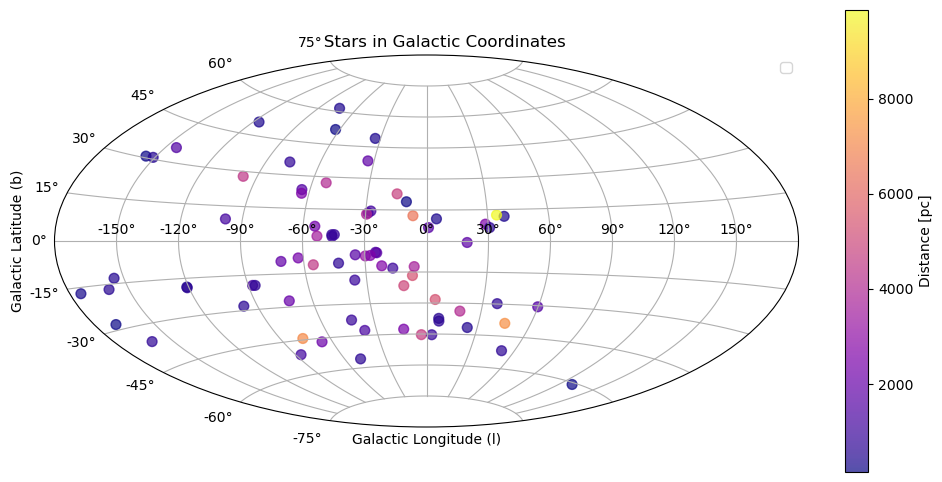

In [9]:
l_rad = galactic_coords.l.wrap_at(180*u.deg).radian  
b_rad = galactic_coords.b.radian

distances = galactic_coords.distance.value

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection="aitoff")
ax.grid(True)


sc = ax.scatter(l_rad, b_rad, c=distances, cmap='plasma', s=50, alpha=0.7)

cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.05)
cbar.set_label("Distance [pc]")

ax.set_title("       Stars in Galactic Coordinates")
ax.set_xlabel("Galactic Longitude (l)")
ax.set_ylabel("Galactic Latitude (b)")
ax.legend()
plt.savefig("AitoffColourBar.png")
plt.show()


PLOTTING POSITION WITH VARYING SIZES \
This is a really similar idea to the prvious plot, the difference being that the size of each point is representative of the distance from the centre. The smaller the dot, the further it is. 

C:\Users\z5481049\AppData\Local\Temp\ipykernel_6412\1135344001.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


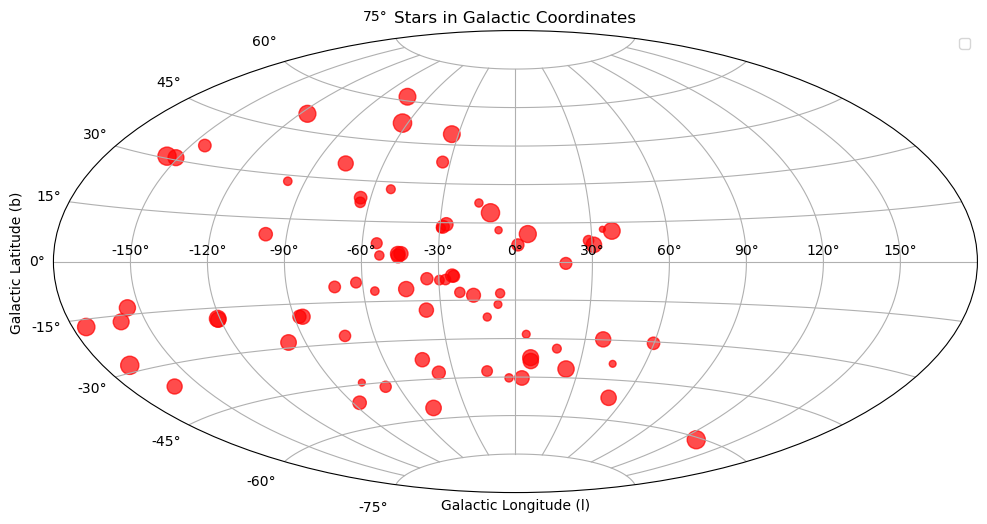

In [10]:
l_rad = galactic_coords.l.wrap_at(180*u.deg).radian  
b_rad = galactic_coords.b.radian

distances = galactic_coords.distance.value

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection="aitoff")
ax.grid(True)

size = 200 / (galactic_coords.distance.value/1000 + 1)

sc = ax.scatter(l_rad, b_rad, c='red', s=size, alpha=0.7)


ax.set_title("Stars in Galactic Coordinates")
ax.set_xlabel("Galactic Longitude (l)")
ax.set_ylabel("Galactic Latitude (b)")
ax.legend()
plt.savefig("AitoffSizeVariation.png")
plt.show()

CARTESIAN COORDINATES \
This is a conversion of the coordinates into cartesian coordinates.


In [11]:
x = galactic_coords.cartesian.x.value  
y = galactic_coords.cartesian.y.value  
z = galactic_coords.cartesian.z.value

print(x, y, z)


[1751.36933327 3987.93939784 -967.89447499 -132.66767744  600.16050554
 -397.2237341  -188.85722019 1106.54652453  702.37107745   43.89257297
 4241.6923317   528.85150808  554.3488143  1308.53029759  485.92688517
 2777.60791486  593.60471332  131.67042523  212.8544029  2156.13412836
  420.6365387   565.85642606 1136.31130671 1047.0330802  4531.61590749
  940.08485181  664.43592987  150.7375304  -142.41843643  228.21303593
  990.35696245  502.91175763 -538.06078286  300.18888719 2141.05235181
 1169.35062102  466.87965827 2498.32922172 1555.66176704   42.76061717
   39.51646325 3273.7808904  4677.97140988 3173.18144511  -99.1948018
 1617.32580057 1069.86278933 1325.44238223 2429.02491697 5059.77294862
   41.86246002 1178.69055791 -314.36710108 -427.40604519 2268.89960277
  525.59603325 7950.9017201   -65.47165523  312.12981041  248.09954877
 1636.7188347   573.90764879 -165.75274821 6291.06836963 3541.33626776
  -55.28748485   50.86120453 -499.65032481 3289.52042493  657.5711303
 -477.61

CARTESIAN PLOT\
This is a cartesian plot for the stars. This was just another way of visualising the stars position. 

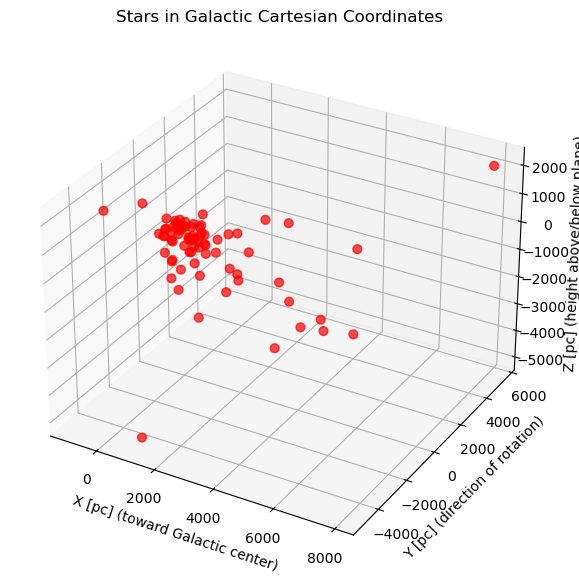

In [12]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(x, y, z, c='red', s=40, alpha=0.7)

ax.scatter(0, 0, 0, color='orange', s=200, marker='*', label='Sun')


ax.set_xlabel('X [pc] (toward Galactic center)')
ax.set_ylabel('Y [pc] (direction of rotation)')
ax.set_zlabel('Z [pc] (height above/below plane)')
ax.set_title('Stars in Galactic Cartesian Coordinates')
plt.savefig("3D.png")
plt.show()

QUIVER PLOT \
Here we are using the proper motions to plot the stars velocity. To do so we use a quiver plot to represent magnitude and direction. Because this plot is 2D, it is difficult to determine exactly what this represents, especially in terms of direction. 

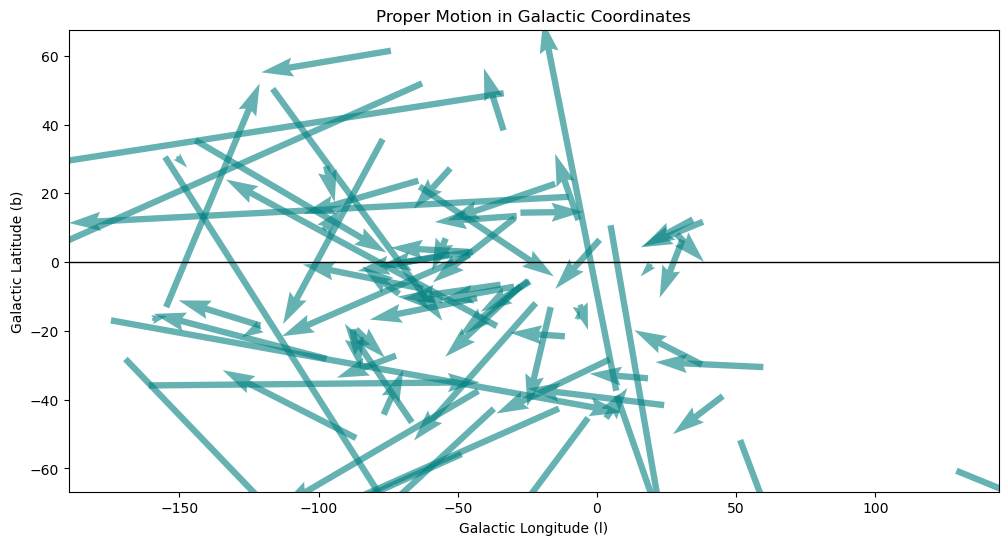

In [13]:
gal = coords.galactic

plt.figure(figsize=(12, 6))

plt.quiver(
    gal.l.wrap_at('180d').degree,
    gal.b.degree,
    gal.pm_l_cosb.value * 50, 
    gal.pm_b.value * 50,
    angles='xy',
    scale_units='xy',
    scale=15,
    color='teal',
    alpha=0.6,
)

plt.axhline(0, color='black', lw=1)
plt.xlabel("Galactic Longitude (l)")
plt.ylabel("Galactic Latitude (b)")
plt.title("Proper Motion in Galactic Coordinates")
plt.savefig("Proper Motion")
plt.show()

TOP DOWN GALAXY PLOT - CARTSIAN COORDINATES\
This plot is to more so get a better look at what we are dealing with. There are two plots here, the first is a view from the top of the galaxy in cartesian with a quiver plot. The second is a slightly more zoomed in version. We convert out coordinates into galactocentric coordinates and also our x and y velocities. These are plotted and the Sun's position in the galaxy is overlaid with the orange star. Zooming in, we see stars travelling in the same direction with a few outliers. 

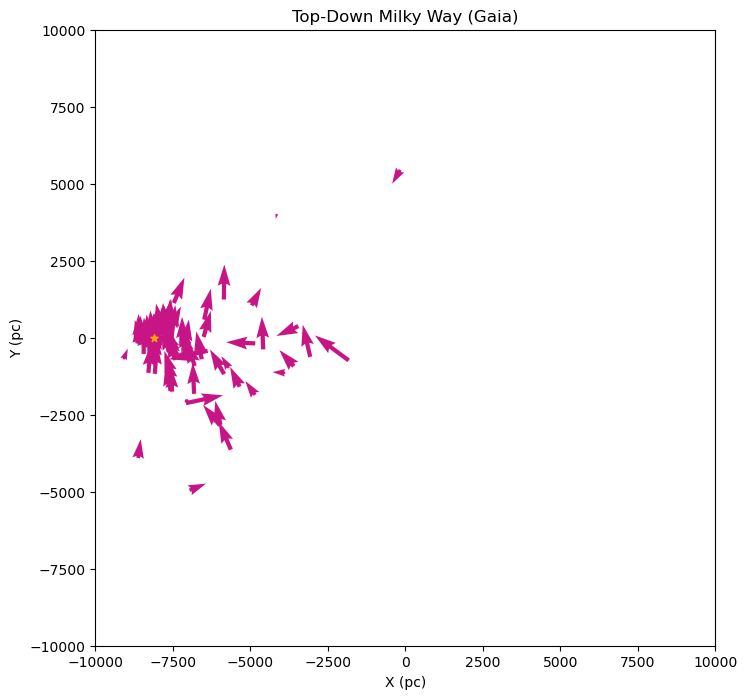

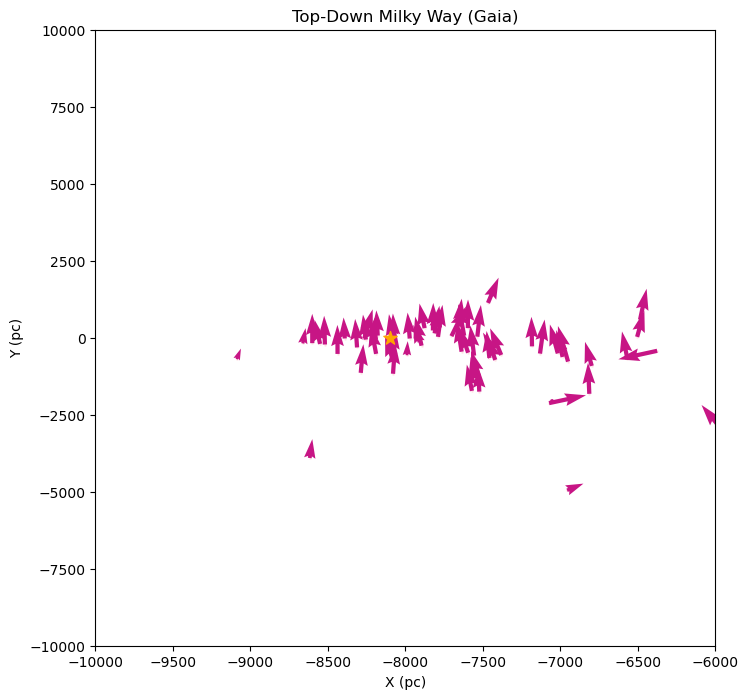

In [44]:
galcen = coords.transform_to(Galactocentric())
x = galcen.cartesian.x.value
y = galcen.cartesian.y.value

vx = galcen.v_x.value
vy = galcen.v_y.value

plt.figure(figsize=(8, 8))
plt.scatter(x, y, s=1, alpha=0.3, color = "pink")

plt.quiver(x, y, vx, vy, scale = 5000, color = "mediumvioletred")
plt.scatter(-8.1*10**3, 0, s=30, color="orange", marker='*')
plt.xlabel("X (pc)")
plt.xlim(-10000, 10000)
plt.ylim(-10000, 10000)
plt.ylabel("Y (pc)")
plt.title("Top-Down Milky Way (Gaia)")
plt.show()


plt.figure(figsize=(8, 8))
plt.scatter(x, y, s=1, alpha=0.3, color = "pink")

plt.quiver(x, y, vx, vy, scale = 5000, color = "mediumvioletred")
plt.scatter(-8.1*10**3, 0, s=100, color="orange", marker='*')
plt.xlabel("X (pc)")
plt.xlim(-10000, -6000)
plt.ylim(-10000, 10000)
plt.ylabel("Y (pc)")
plt.title("Top-Down Milky Way (Gaia)")
plt.show()

In [72]:
parallax_rad_vel_mask = (gaia_results['parallax'] >= 0) & (~np.isnan(gaia_results['radial_velocity']))

feh_list = []
for star in star_IDs[parallax_rad_vel_mask]:
    mask = data['gaiadr3_source_id'] == star
    feh_list.append(data['fe_h'][mask][0])

feh_array = np.array(feh_list)
print(len(feh_list))

82


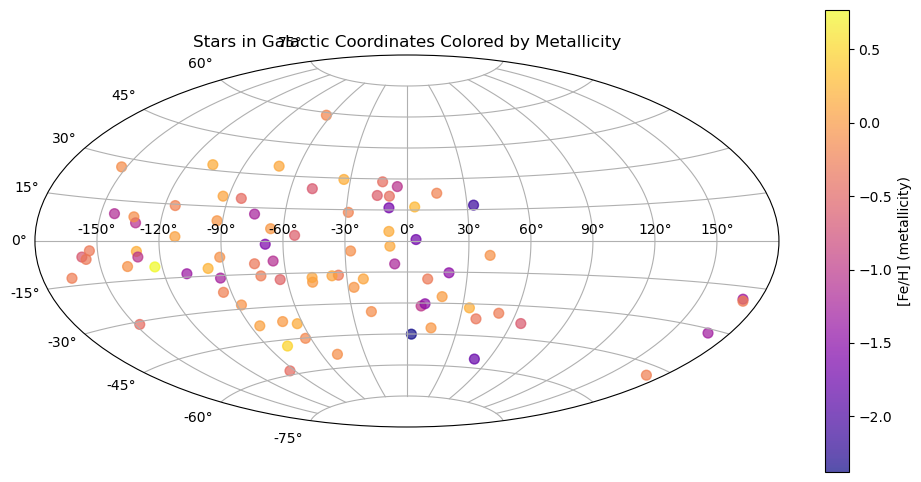

In [73]:
gal = coords.galactic
l_rad = gal.l.wrap_at(180*u.deg).radian
b_rad = gal.b.radian

# 3. Aitoff scatter plot with colormap based on metallicity
plt.figure(figsize=(12,6))
plt.subplot(111, projection='aitoff')
sc = plt.scatter(l_rad, b_rad, c=feh_array, s=50, alpha=0.7, cmap='plasma')
plt.grid(True)
plt.colorbar(sc, label='[Fe/H] (metallicity)')
plt.title("Stars in Galactic Coordinates Colored by Metallicity")
plt.show()

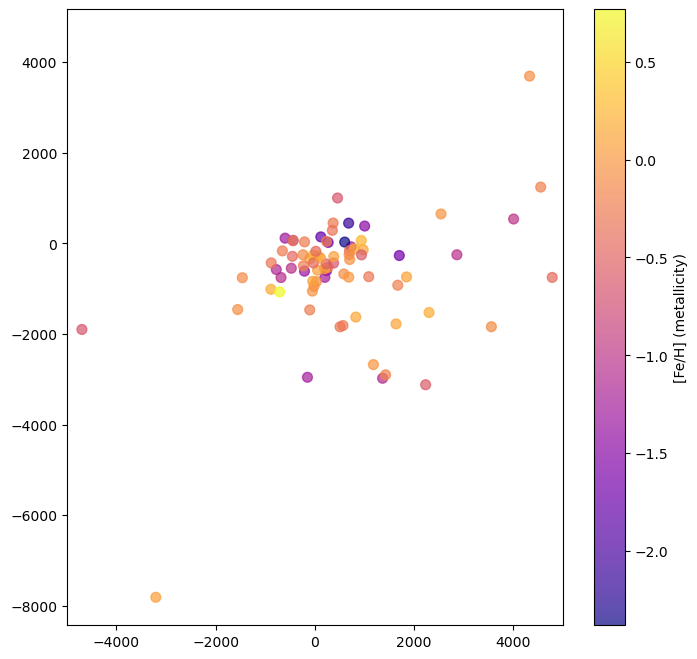

In [81]:
x = distances * np.cos(gal.b.radian) * np.cos(gal.l.radian)
y = distances * np.cos(gal.b.radian) * np.sin(gal.l.radian)

k = 4.74  
v_l = k * gal.pm_l_cosb.value * distances
vx = -v_l * np.sin(gal.l.radian)
vy =  v_l * np.cos(gal.l.radian)

plt.figure(figsize=(8, 8))
sc = plt.scatter(x, y, alpha=0.7, c=feh_array, s=50, cmap='plasma')
plt.xlim(-5000, 5000)
plt.colorbar(sc, label='[Fe/H] (metallicity)')

In [184]:
k = 4.74  

dist_pc = gal.distance.value  

v_l = k * gal.pm_l_cosb.value * dist_pc / 1000
v_b = k * gal.pm_b.value * dist_pc / 1000

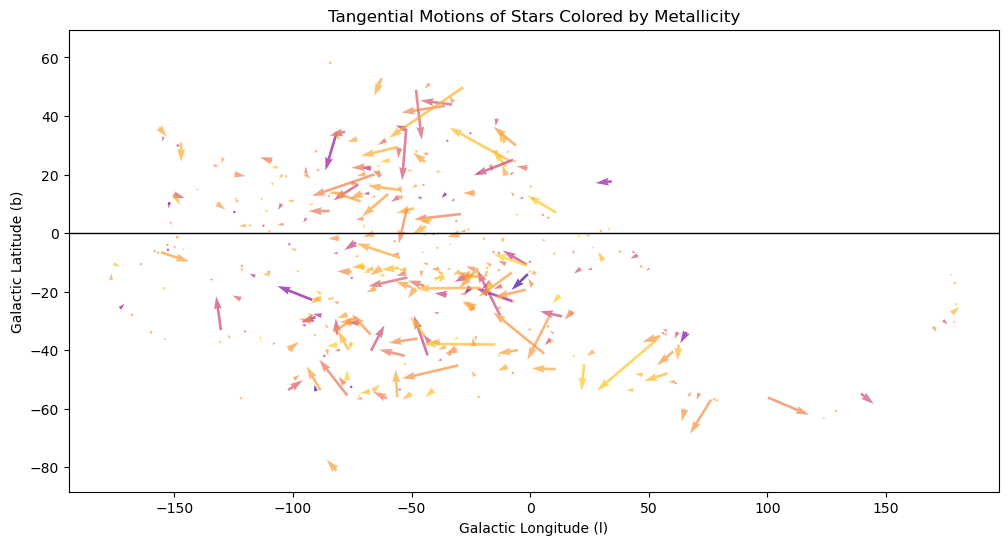

In [186]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sc = plt.quiver(
    gal.l.wrap_at('180d').degree,   # x = Galactic longitude
    gal.b.degree,                   # y = Galactic latitude
    v_l,                            # arrow x-component (km/s)
    v_b,                            # arrow y-component (km/s)
    angles='xy',
    scale_units='xy',
    scale=20,                       # adjust scale to fit plot
    color=plt.cm.plasma((feh_array - feh_array.min()) / (feh_array.max() - feh_array.min())),  # color by metallicity
    alpha=0.7
)
plt.axhline(0, color='black', lw=1)
plt.xlabel("Galactic Longitude (l)")
plt.ylabel("Galactic Latitude (b)")
plt.title("Tangential Motions of Stars Colored by Metallicity")

rv = gal.radial_velocity.value
rv_norm = (rv - np.min(rv)) / (np.max(rv) - np.min(rv))


https://ned.ipac.caltech.edu/level5/Sept08/Matteucci/Matteucci3.html

In [188]:
halo_mask = feh_array < -1
thin_disk_mask = (feh_array >= -0.8) & (feh_array <= -0.4)
bulge_mask = (feh_array > -0.4) & (feh_array <= 0)

In [190]:
galcen = coords.transform_to(Galactocentric())
U = galcen.v_x.to(u.km/u.s).value  # radial toward Galactic center
V = galcen.v_y.to(u.km/u.s).value  # rotation around Galactic center
W = galcen.v_z.to(u.km/u.s).value 

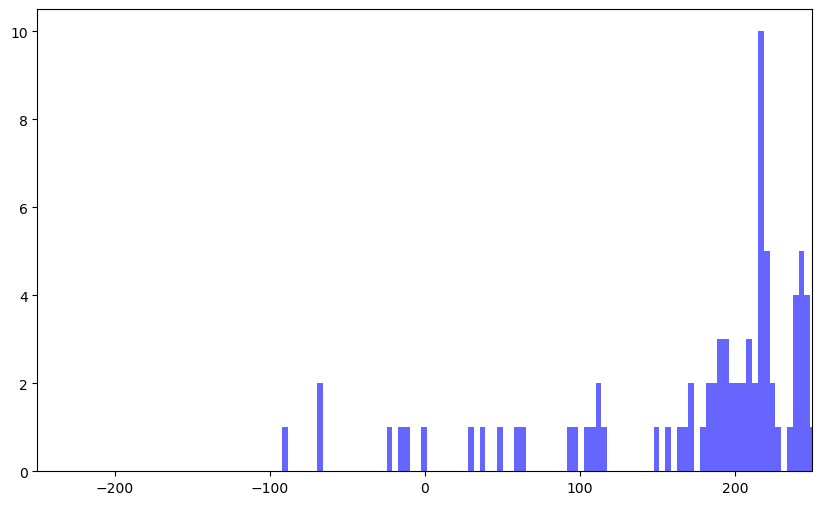

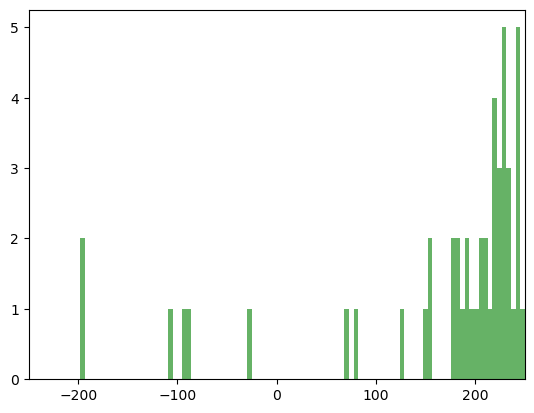

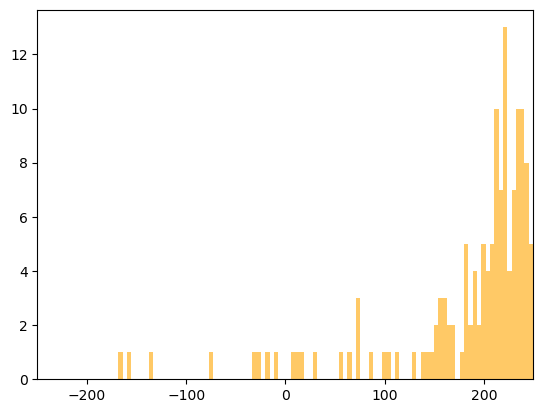

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


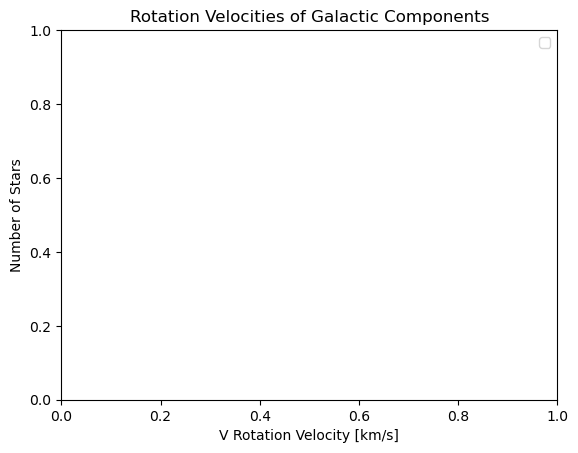

In [192]:
plt.figure(figsize=(10,6))
plt.xlim(-250,250)
plt.hist(V[halo_mask], bins=100, alpha=0.6, color='blue', label='Halo ([Fe/H]<-1)')
plt.show()
plt.xlim(-250,250)
plt.hist(V[thin_disk_mask], bins=100, alpha=0.6, color='green', label='Thin Disk (-0.8<[Fe/H]<-0.4)')
plt.show()
plt.xlim(-250,250)
plt.hist(V[bulge_mask], bins=100, alpha=0.6, color='orange', label='Bulge (-0.4<[Fe/H]<0)')
plt.show()
plt.xlabel("V Rotation Velocity [km/s]")
plt.ylabel("Number of Stars")
plt.title("Rotation Velocities of Galactic Components")
plt.legend()


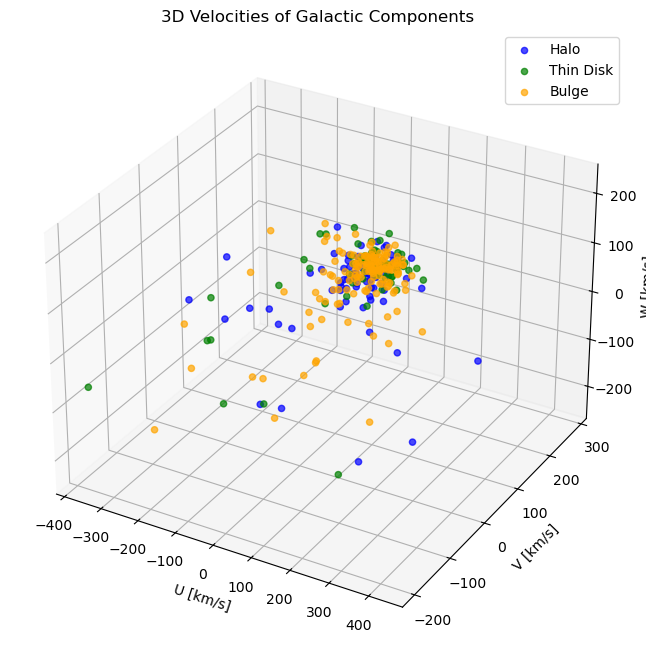

In [194]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(U[halo_mask], V[halo_mask], W[halo_mask], color='blue', label='Halo', alpha=0.7)
ax.scatter(U[thin_disk_mask], V[thin_disk_mask], W[thin_disk_mask], color='green', label='Thin Disk', alpha=0.7)
ax.scatter(U[bulge_mask], V[bulge_mask], W[bulge_mask], color='orange', label='Bulge', alpha=0.7)

ax.set_xlabel('U [km/s]')
ax.set_ylabel('V [km/s]')
ax.set_zlabel('W [km/s]')
ax.set_title('3D Velocities of Galactic Components')
ax.legend()
plt.show()

In [196]:
from astropy.coordinates import Galactocentric

galcen = coords.transform_to(Galactocentric())
U = galcen.v_x.to(u.km/u.s).value  # toward Galactic center
V = galcen.v_y.to(u.km/u.s).value  # rotation direction
W = galcen.v_z.to(u.km/u.s).value

In [198]:
disk_mask = (feh_array > -1) & (feh_array < 0.1)  # thin + thick disk
V_disk = V[disk_mask]

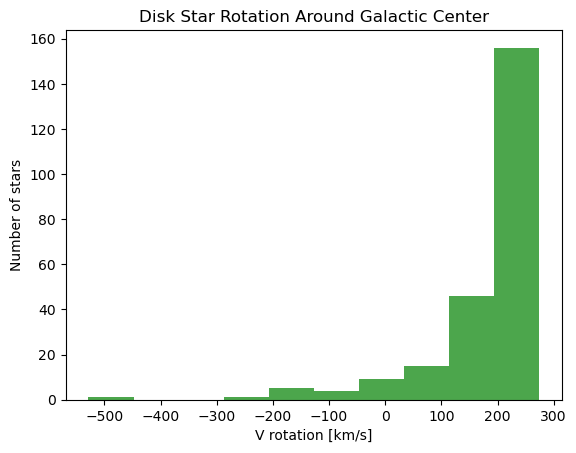

In [200]:
import matplotlib.pyplot as plt

plt.hist(V_disk, bins=10, alpha=0.7, color='green')
plt.xlabel("V rotation [km/s]")
plt.ylabel("Number of stars")
plt.title("Disk Star Rotation Around Galactic Center")
plt.show()

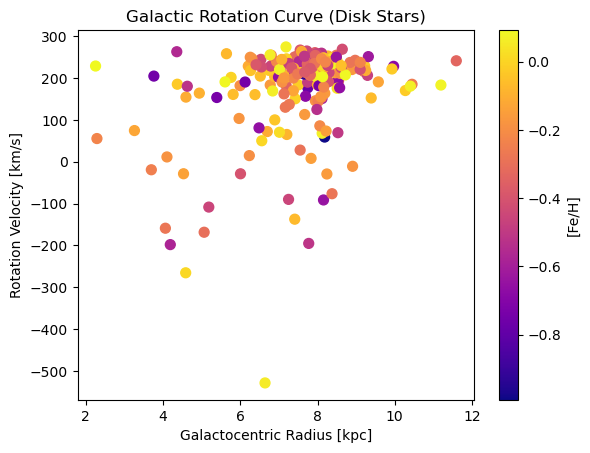

In [202]:
R = np.sqrt(galcen.x.value**2 + galcen.y.value**2)  # distance in pc
V_disk = V[disk_mask]
R_disk = R[disk_mask]

plt.scatter(R_disk/1000, V_disk, c=feh_array[disk_mask], cmap='plasma', s=50)
plt.xlabel("Galactocentric Radius [kpc]")
plt.ylabel("Rotation Velocity [km/s]")
plt.title("Galactic Rotation Curve (Disk Stars)")
plt.colorbar(label='[Fe/H]')
plt.show()

In [204]:
V_disk = V[disk_mask]
V_disk_all = V[disk_mask]

V_disk = V_disk_all[~np.isnan(V_disk_all)]


In [206]:
mean_rotation = np.mean(V_disk)
std_rotation = np.std(V_disk)
N = len(V_disk)
std_error = std_rotation / np.sqrt(N)

print(f"Estimated rotation velocity: {mean_rotation:.1f} ± {std_error:.1f} km/s")

Estimated rotation velocity: 180.8 ± 6.7 km/s


In [208]:
lower = mean_rotation - std_error
upper = mean_rotation + std_error
print(f"Rotation velocity ~ {mean_rotation:.1f} km/s (+{upper-mean_rotation:.1f}/-{mean_rotation-lower:.1f})")

Rotation velocity ~ 180.8 km/s (+6.7/-6.7)
